# Segmentation-free spatial proteomics analysis (MACSima)

This notebook covers segmentation-free approaches, superpixel clustering and pixel/cell clustering with FlowSOM, for a MACSima spatial proteomics dataset. It continues from `6.proteomics_macsima.ipynb`, assuming the preprocessed `SpatialData` object is already available.

## Fetch the data

In [ ]:
import os
import sys
import tempfile
from pathlib import Path

import harpy as hp
from spatialdata import read_zarr

if sys.platform == "win32":
    # Force short paths to avoid running into Windows limitation with path > 260 characters.
    temp_dir = "c:\\tmp"
    course_data_cache_path = "c:\\hp_cache"
    os.makedirs(temp_dir, exist_ok=True)
else:
    temp_dir = None  # use OS default
    course_data_cache_path = None  # use OS default

tmp = tempfile.TemporaryDirectory(dir=temp_dir, prefix="macsima_")
output_dir = Path(tmp.name)

sdata = hp.datasets.macsima_colorectal_carcinoma_course(
    checkpoint="checkpoint_2",
    path=course_data_cache_path,
)

sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

WARNING  Module 'bioio' is not installed. Install it with `pip install bioio` to use `harpy.io.macsima`.           
WARNING  Module 'bioio-ome-tiff' is not installed. Install it with `pip install bioio-ome-tiff` to use             
         `harpy.io.macsima`.                                                                                       


no parent found for <ome_zarr.reader.Label object at 0x1634ecd10>: None
no parent found for <ome_zarr.reader.Label object at 0x16361ab10>: None
no parent found for <ome_zarr.reader.Label object at 0x1636305c0>: None
no parent found for <ome_zarr.reader.Label object at 0x1636322a0>: None
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/Users/arne.defauw/.local/share/uv/python/cpython-3.12.12-macos-

2026-06-17 09:54:28.612 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.008s (26441.53 instances/s).
2026-06-17 09:54:28.614 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.007s (28078.21 instances/s).
2026-06-17 09:54:28.634 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.019s (11151.11 instances/s).
2026-06-17 09:54:28.662 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.016s (15510.04 instances/s).
2026-06-17 09:54:28.677 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.027s (9187.31 instances/s).
2026-06-17 09:54:28.702 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.050s (4239.12 instances/s).


## 1. Superpixel clustering

In [2]:
successful_channels = [
    "DAPI",
    "Bcl 2",  # Clearly contains acquisition bleaching artifacts, but we can annotate these regions to remove them
    "CD8a",
    "FoxP3",
    "CD138",
    "CD15",
    "CD45",
    "Collagen I",
    "CD274",
    "PCNA",
    "CD163",
    "CD56",
    "CD11b",
    "CD45RB",
    "CD14",
    "CD107a",
    "Ki 67",
    "CD4",
    "CD107b",
    "CD31",
    "CD38",
    "CD66b",
    "Cleaved PARP1",
    "Mast Cell Tryptase",
    "CD20 Cytoplasmic",
    "Podoplanin",
    "CD16",
    "CD1c",
    "Actin",
    "CD68",
    "Cytokeratin 20",
    "CD79a",
    "CD45RO",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD324",
    "HLA ABC",
    "CD57",
    "CD204",
    "MART 1",
    "Melanocyte PMEL",
    "Cytokeratin 19",
    "Cytokeratin",
    "HLA DR",
    "beta Catenin",
    "beta Actin",
    "CD326",
    "Calponin",
]

In [3]:
import harpy as hp

shape = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC_normalized").shape[1:]
shape

(3000, 3000)

In [4]:
from spatialdata.transformations import get_transformation

size = 50.0  # -> Circumradius (center → vertex ) | Height = 2*size | Width = √3·size ≈ 1.732·size.

sdata = hp.im.add_grid_labels(
    sdata,
    shape=shape,
    size=size,
    output_shapes_name=f"shapes_grid_{size}",
    output_labels_name=f"labels_grid_{size}",
    grid_type="hexagon",  # Set to 'square' for square grid
    offset=(0, 0),
    chunks=1024,
    client=None,
    transformations=get_transformation(sdata["REAscreen_IO_CRC_normalized"], get_all=True),
    scale_factors=(2, 2, 2, 2),
    overwrite=True,
)

2026-06-17 09:52:00.186 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_grid_50.0'
no parent found for <ome_zarr.reader.Label object at 0x165f3d700>: None
no parent found for <ome_zarr.reader.Label object at 0x1634e0ce0>: None
no parent found for <ome_zarr.reader.Label object at 0x16597d790>: None
no parent found for <ome_zarr.reader.Label object at 0x16615ea20>: None


In [5]:
# Allocate intensities
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    labels_name=f"labels_grid_{size}",
    output_table_name="table_superpixel_intensities",
    channels=successful_channels,
    mode="mean",  # Can be set to "mean" or "sum"
    to_coordinate_system="global_1",
    overwrite=True,
)

2026-06-17 09:52:02.946 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


In [6]:
from napari_harpy import Interactive

Interactive(sdata)

In [7]:
# z-scoring before leiden clustering

sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_name=f"labels_grid_{size}",
    table_name="table_superpixel_intensities",
    output_table_name="table_superpixel_intensities_z_scored",
    calculate_cell_size=False,
    size_norm=False,
    library_norm=False,
    log1p=False,
    scale=True,
    max_value_scale=5,
    q=None,
    calculate_pca=False,
    raw_counts_key="mean_counts",
    overwrite=True,
)

2026-06-17 09:52:16.888 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[mean_counts]'.


2026-06-17 09:52:27.276 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_superpixel_intensities_z_scored' already exists. Overwriting...


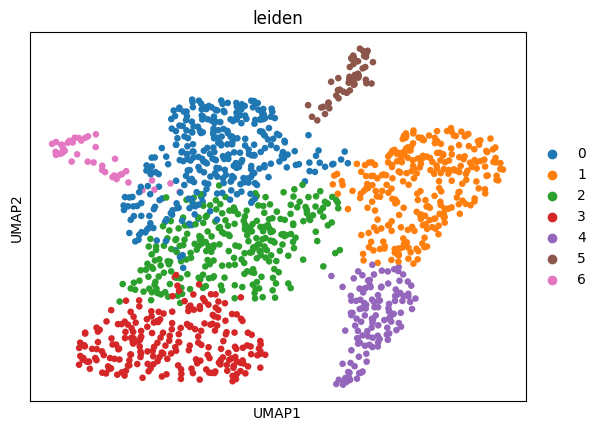

In [8]:
import scanpy as sc

# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_name=f"labels_grid_{size}",
    table_name="table_superpixel_intensities_z_scored",
    output_table_name="table_superpixel_intensities_z_scored",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_superpixel_intensities_z_scored"],
    color=["leiden"],
    show=True,
)

<Axes: title={'center': 'Leiden clusters'}>

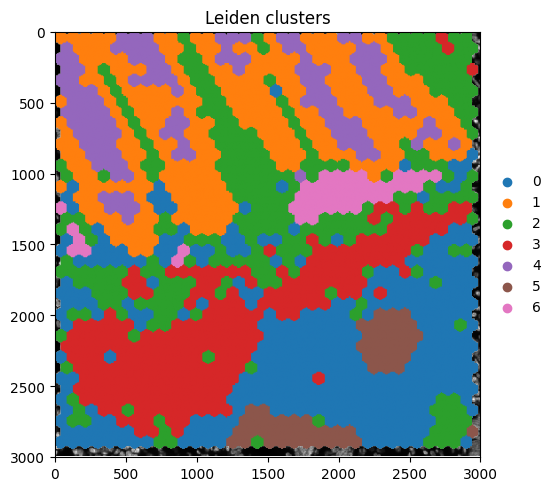

In [9]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_superpixel_intensities_z_scored",
    labels_name=f"labels_grid_{size}",
    color="leiden",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

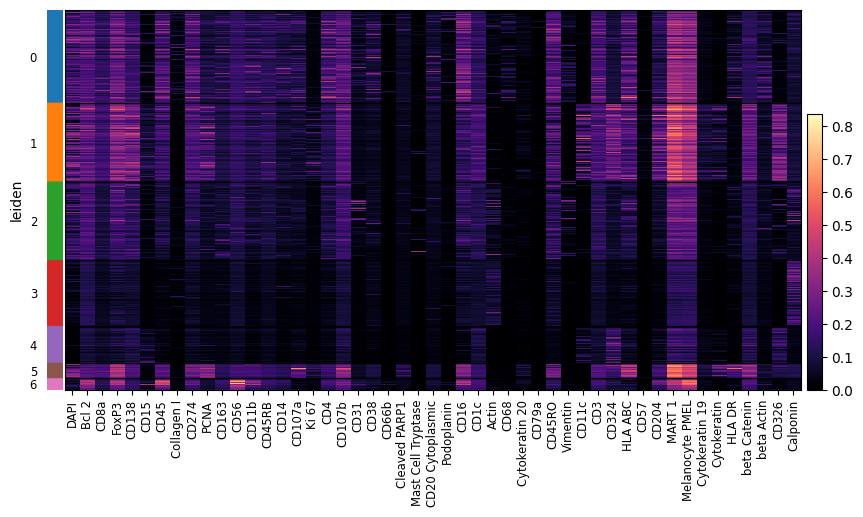

In [10]:
sc.pl.heatmap(
    sdata["table_superpixel_intensities_z_scored"],
    var_names=successful_channels,
    groupby="leiden",
    swap_axes=False,
    norm=None,
    cmap="magma",
    figsize=(10, 5),
    show_gene_labels=True,
)

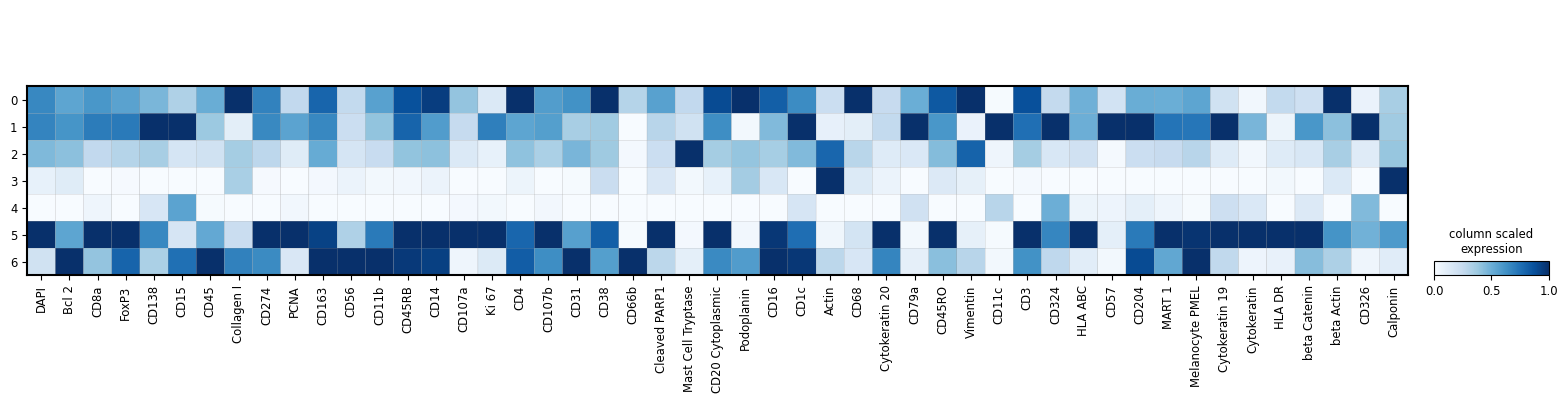

In [11]:
# Matrix plot
sc.pl.matrixplot(
    sdata.tables["table_superpixel_intensities_z_scored"],
    var_names=successful_channels,
    groupby="leiden",
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
)

## 2. Pixel clustering (FlowSOM)

FlowSOM pixel and cell clustering as implemented in Harpy provides a scalable implementation of the unsupervised pixel and cell level clustering approach described in Liu, C.C., Greenwald, N.F., Kong, A., et al. (2023). Robust phenotyping of highly multiplexed tissue imaging data using pixel-level clustering. Nature Communications, 14, 4618. https://doi.org/10.1038/s41467-023-40068-5.

This implementation follows the methodology of the original [ark-analysis](https://github.com/angelolab/ark-analysis) repository but has been reengineered for compatibility with SpatialData and leverages Dask for efficient scaling to gigapixel-scale images.

### 2.1 Preprocessing

In [12]:
# The preprocessing step normalizes and blurs the images based on various quantile and gaussian blur parameters
sdata = hp.im.pixel_clustering_preprocess(
    sdata,
    image_name="REAscreen_IO_CRC",
    output_image_name="REAscreen_IO_CRC_flowsom",
    channels=successful_channels,
    p=99,  # Quantile used for normalization. Each channel is normalized by its own calculated quantile.
    p_sum=5,  # If the sum of the channel values at a pixel is below this quantile, the pixel values across all channels are set to NaN.
    p_post=99.9,  # Quantile used for normalization after other preprocessing steps (`q`, `q_sum`, `norm_sum` normalization and Gaussian blurring) are performed.
    sigma=2,  # Gaussian blur parameter for each channel. Use `0` to omit blurring for specific channels or `None` to skip blurring altogether.
    norm_sum=True,  # If `True`, each channel is normalized by the sum of all channels at each pixel.
    cap_max=1,  # The maximum allowable value for the elements in the resulting preprocessed image layers. If `None`, no capping is applied. Typical value would be `1.0` to exclude outliers.
    overwrite=True,
)

2026-06-17 09:52:30.376 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_flowsom'


In [13]:
Interactive(sdata)

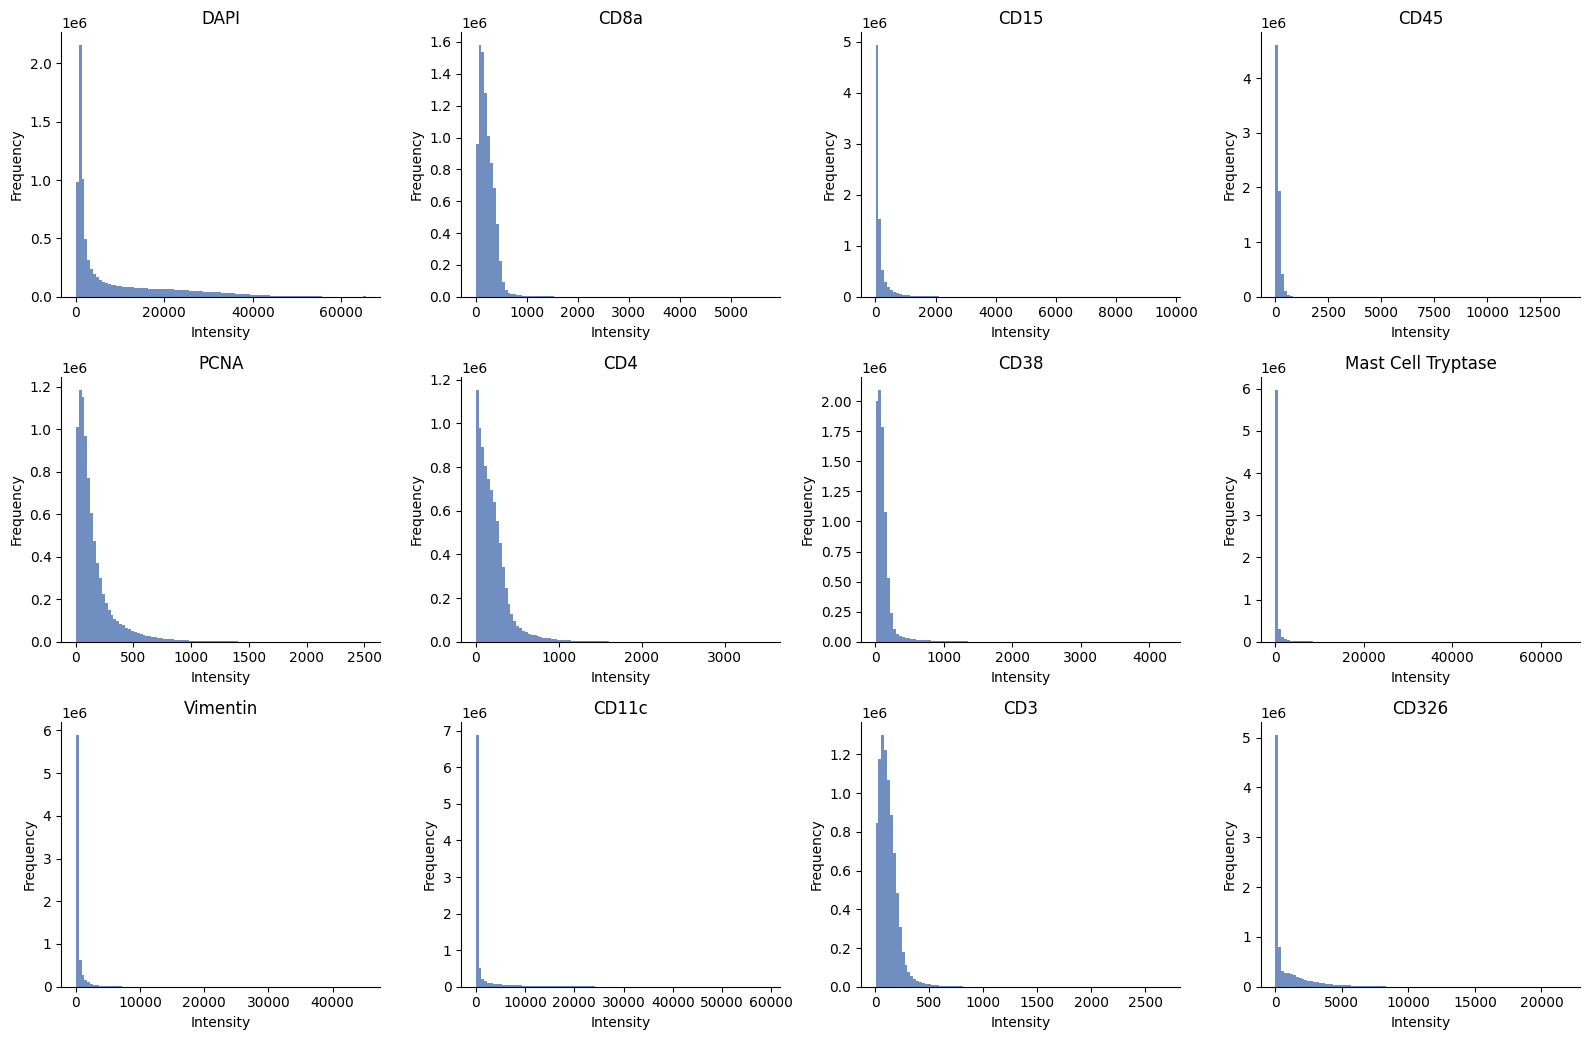

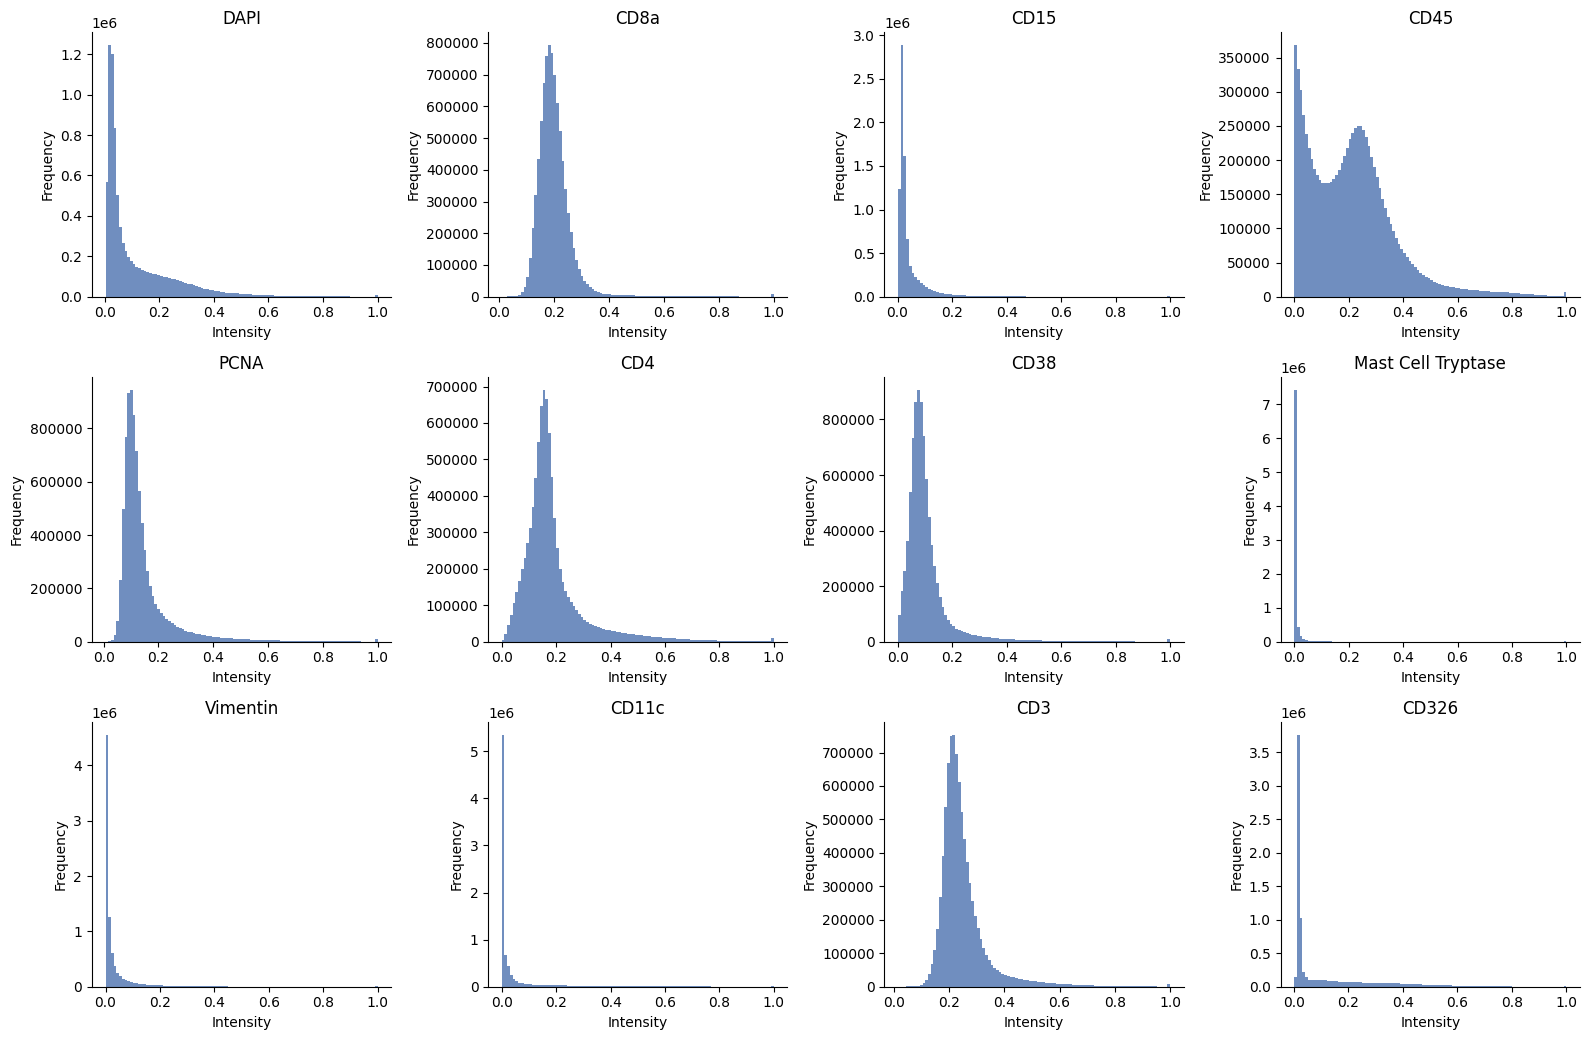

In [14]:
_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC_flowsom",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

### 2.2 FlowSOM pixel clustering

FlowSOM performs clustering in two steps. First, it trains a self-organizing map (SOM), which overclusters high-dimensional marker profiles into many small prototype nodes arranged on a 2D grid. Second, it groups these SOM nodes into a smaller number of metaclusters using agglomerative clustering, giving both fine-grained cluster labels and broader metacluster labels. Here we use the `flowsom` Python library from [saeyslab/FlowSOM_Python](https://github.com/saeyslab/FlowSOM_Python), a Python implementation of the original FlowSOM method described by Van Gassen et al. in [FlowSOM: Using self-organizing maps for visualization and interpretation of cytometry data](https://onlinelibrary.wiley.com/doi/10.1002/cyto.a.22625).

In this notebook, `hp.im.flowsom` runs FlowSOM on the preprocessed image `REAscreen_IO_CRC_flowsom`. It samples a fraction of pixels for training, learns a `10 x 10` SOM on the selected marker channels, groups the 100 SOM nodes into `20` metaclusters, and then predicts cluster and metacluster labels for all pixels in the image. The results are written back to `sdata` as the label layers `flowsom_clusters` and `flowsom_metaclusters`. Pixels filtered out during preprocessing remain labeled `0`.

In [15]:
# FlowSOM clustering
import flowsom as fs
from dask.distributed import Client, LocalCluster

work_with_client = False

if work_with_client:
    # client example
    cluster = LocalCluster(
        n_workers=1,
        threads_per_worker=10,
    )

    client = Client(cluster)
else:
    client = None

batch_model = fs.models.BatchFlowSOMEstimator

sdata_crop, fsom, mapping = hp.im.flowsom(
    sdata,
    image_name=["REAscreen_IO_CRC_flowsom"],
    output_cluster_labels_name=[
        "flowsom_clusters",
    ],  # we need output_cluster_labels and output_meta_cluster_labels --> these will both be labels elements
    output_metacluster_labels_name=[
        "flowsom_metaclusters",
    ],
    channels=successful_channels,
    fraction=0.1,  # Fraction of the data to sample for training flowsom.
    n_clusters=20,  # The number of meta clusters to form.
    random_state=111,
    chunks=512,
    client=client,
    model=batch_model,
    num_batches=10,
    xdim=10,
    ydim=10,
    z_score=False,
    z_cap=3,
    persist_intermediate=True,
    overwrite=True,
)

2026-06-17 09:52:48.877 | INFO     | harpy.image.pixel_clustering._clustering:flowsom:161 - Extracting random sample for FlowSOM training.
2026-06-17 09:52:52.386 | INFO     | harpy.image.pixel_clustering._clustering:_sample_dask_array:398 - Start sampling
2026-06-17 09:52:54.338 | INFO     | harpy.image.pixel_clustering._clustering:flowsom:219 - Start FlowSOM training.
2026-06-17 09:52:54.343 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-06-17 09:52:54.344 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-06-17 09:53:00.599 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.
2026-06-17 09:53:03.900 | INFO     | harpy.image.pixel_clustering._clustering:flowsom:221 - Finished FlowSOM training. Starting inference 
2026-06-17 09:53:06.823 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'flowsom_clusters'
no parent found for <ome_zarr.reader.Label object at 0x350954620>: None
no parent found f

<Axes: title={'center': 'Metaclusters'}>

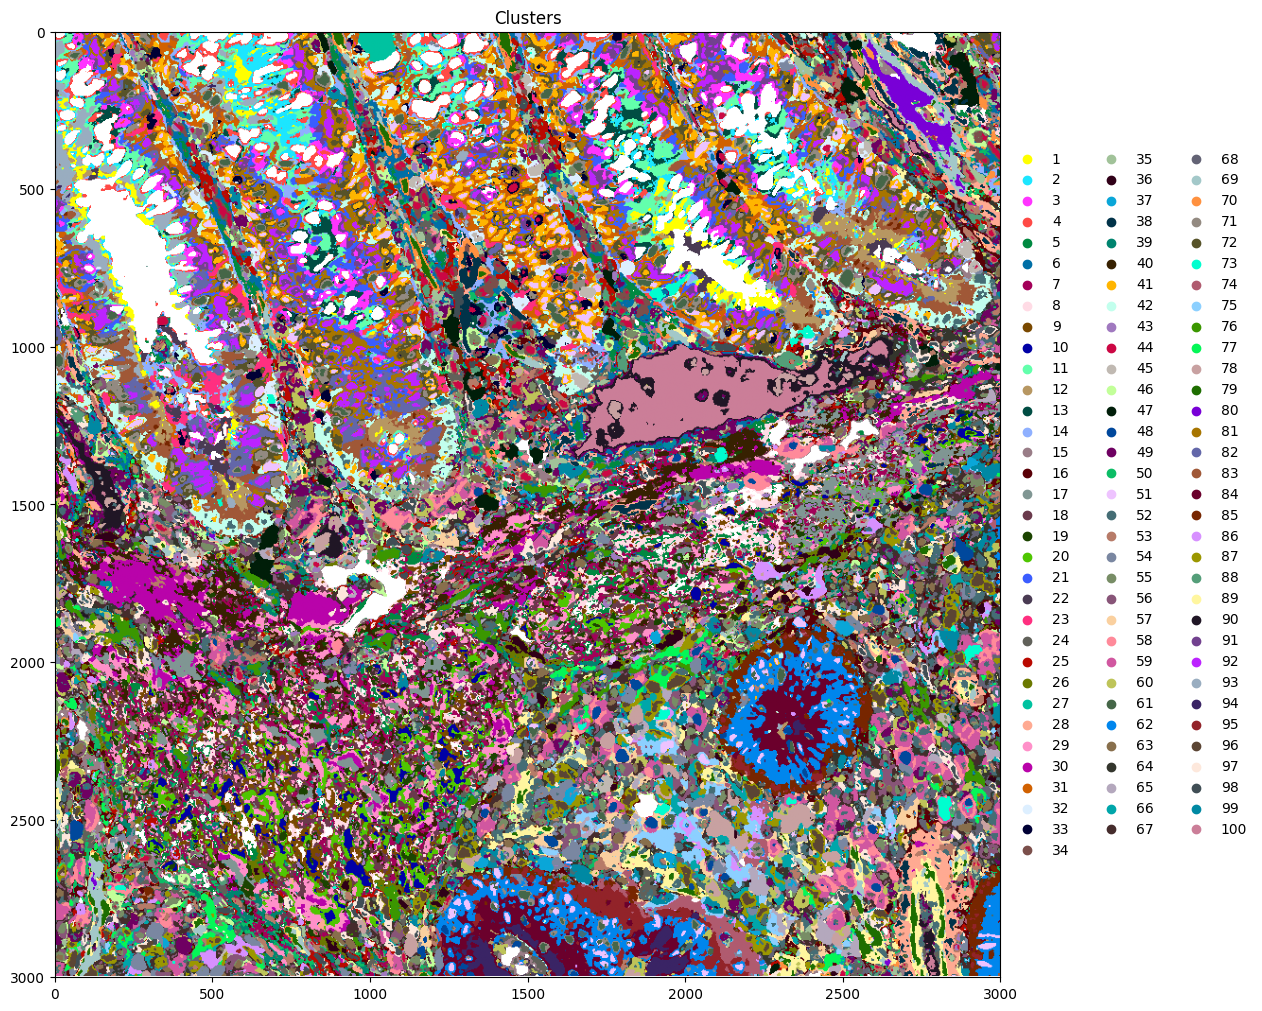

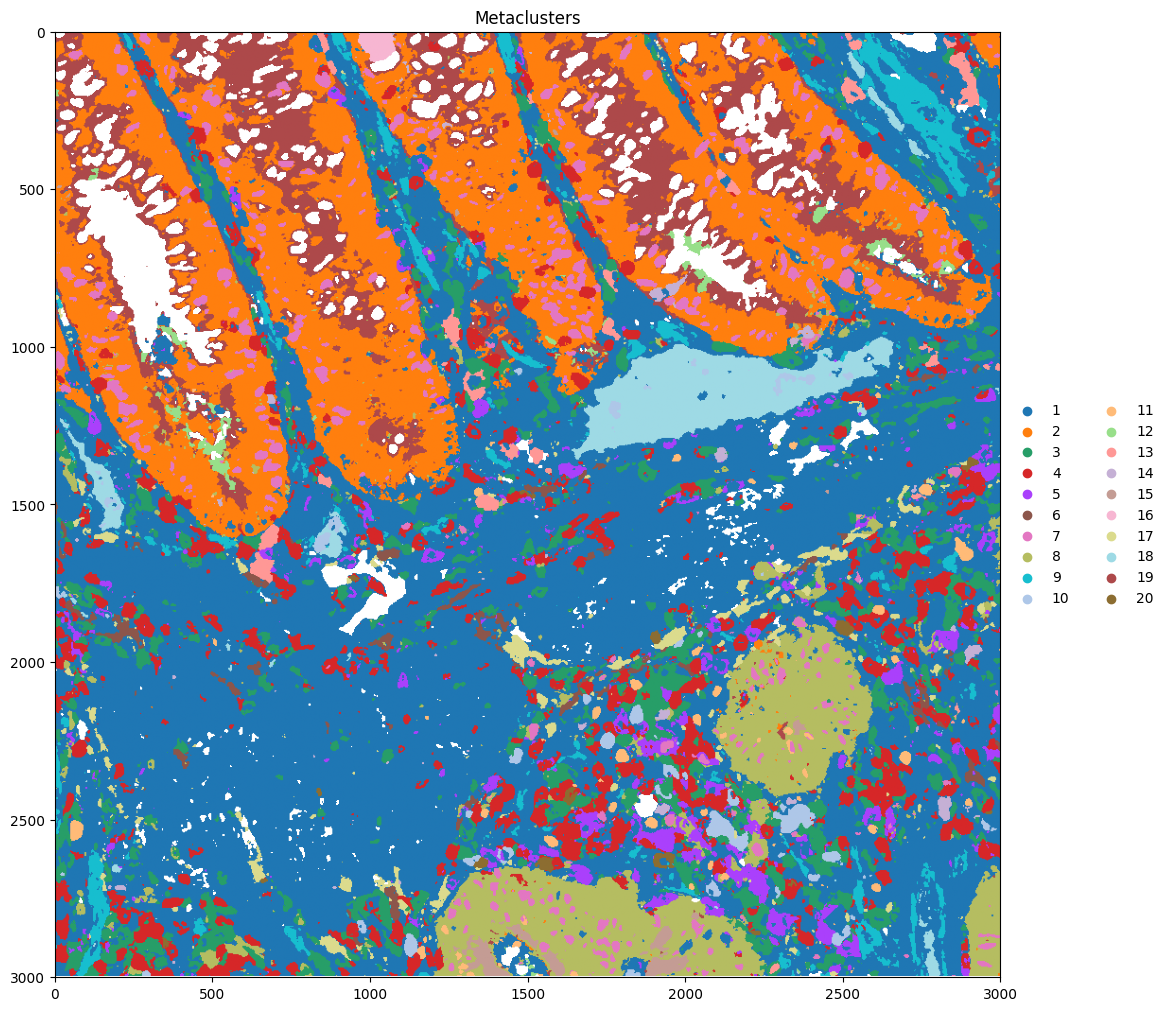

In [16]:
# Plot all FlowSOM clusters
hp.pl.pixel_clusters(
    sdata,
    labels_name="flowsom_clusters",
    figsize=(14, 10),
    to_coordinate_system="global_1",
    render_labels_kwargs={
        "fill_alpha": 1,
        "cmap": "rainbow",
    },
    coordinate_systems="global_1",
    title="Clusters",
)

# Plot FlowSOM metaclusters
hp.pl.pixel_clusters(
    sdata,
    labels_name="flowsom_metaclusters",
    figsize=(14, 10),
    to_coordinate_system="global",
    render_labels_kwargs={
        "fill_alpha": 1,
        "cmap": "rainbow",
    },
    coordinate_systems="global_1",
    title="Metaclusters",
)

2026-06-17 09:53:16.489 | INFO     | harpy.table.pixel_clustering._cluster_intensity:cluster_intensity_SOM:120 - Start allocation of intensities of image element with name 'REAscreen_IO_CRC_flowsom' by labels in labels element with name 'flowsom_clusters'.
2026-06-17 09:53:20.384 | INFO     | harpy.table.pixel_clustering._cluster_intensity:cluster_intensity_SOM:139 - End allocation of image element with name 'REAscreen_IO_CRC_flowsom' and labels element with name 'flowsom_clusters'.
2026-06-17 09:53:20.385 | INFO     | harpy.table.pixel_clustering._cluster_intensity:cluster_intensity_SOM:143 - Start preprocessing.
2026-06-17 09:53:20.386 | INFO     | harpy.table._preprocess:preprocess:318 - Calculating cell size from provided labels_name 'flowsom_clusters'
2026-06-17 09:53:20.491 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[raw_counts]'.
2026-06-17 09:53:21.486 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 -

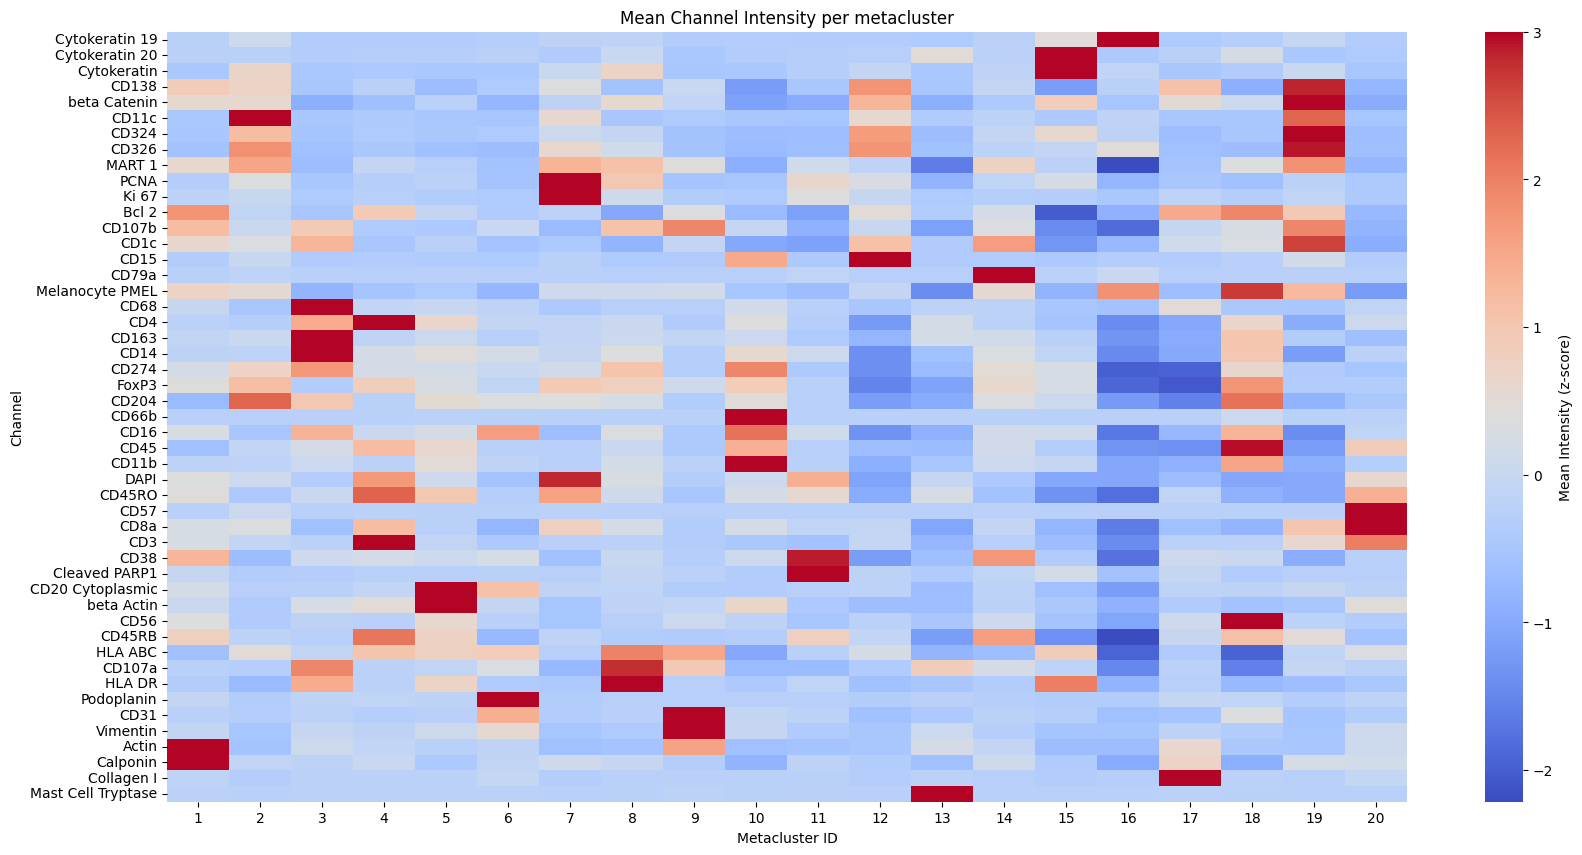

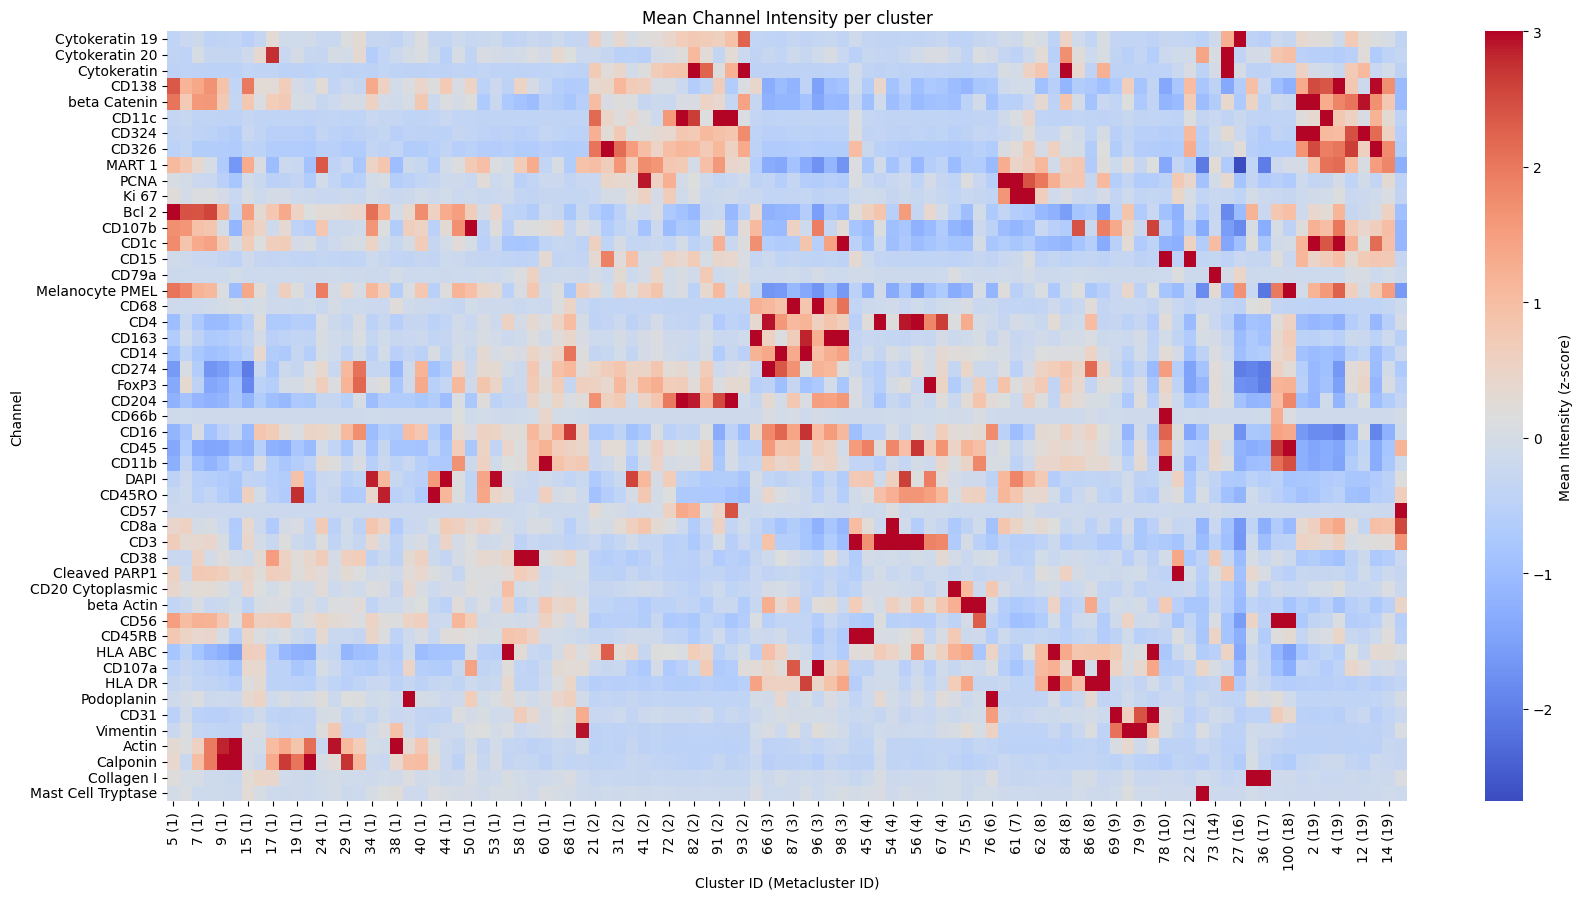

In [17]:
# calculate the mean itensity per metacluster, and then plot a heatmap.
cluster_key = "leiden"

sdata = hp.tb.cluster_intensity_SOM(
    sdata,
    mapping=mapping,
    image_name="REAscreen_IO_CRC_flowsom",
    labels_name="flowsom_clusters",
    to_coordinate_system="global_1",
    output_table_name="counts_clusters",
    overwrite=True,
)

for _metaclusters in [True, False]:
    hp.pl.pixel_clusters_heatmap(
        sdata,
        table_name="counts_clusters",
        figsize=(20, 10),
        fig_kwargs={"dpi": 100},
        linewidths=0.001,
        metaclusters=_metaclusters,
        z_score=True,
    )

### 2.3 Spatial enrichment FlowSOM metaclusters 

We can use hp.tb.spatial_pixel_neighbors() after calculating FlowSOM metaclusters to get neighborhood enrichment scores among metaclusters. This function extracts grid-based cluster labels from the specified labels layer of a SpatialData object,
subdivides the spatial domain into a grid using a specified sampling interval, and computes spatial neighbors along with
neighborhood enrichment statistics. The resulting AnnData object stores the cluster labels as a categorical
observation (under the key provided by `key_added`) and the corresponding spatial coordinates in its `.obsm`
attribute. `squidpy` is used for the spatial neighbors computation and
the neighborhood enrichment analysis (i.e. `squidpy.gr.spatial_neighbors` and `squidpy.gr.nhood_enrichment`).
Results can then be visualized using e.g. `squidpy.pl.nhood_enrichment`.

2026-06-17 09:54:27.006 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_grid_56ca5a53-2bd5-44af-bba9-0e87d853d0b3'
no parent found for <ome_zarr.reader.Label object at 0x350845670>: None
no parent found for <ome_zarr.reader.Label object at 0x350899670>: None
no parent found for <ome_zarr.reader.Label object at 0x343afef60>: None
no parent found for <ome_zarr.reader.Label object at 0x33a2ce090>: None
no parent found for <ome_zarr.reader.Label object at 0x350a17710>: None
no parent found for <ome_zarr.reader.Label object at 0x350a7c290>: None
no parent found for <ome_zarr.reader.Label object at 0x332163410>: None
2026-06-17 09:54:28.248 | INFO     | harpy.utils._featurize:__init__:93 - Calculating unique labels in the mask.
2026-06-17 09:54:28.293 | INFO     | harpy.utils._featurize:__init__:96 - Finished calculating unique labels in the mask.
2026-06-17 09:54:28.294 | INFO     | harpy.utils._featurize:extract_instances:795 - Calculating center of ma

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


  0%|          | 0/1000 [00:00<?, ?/s]

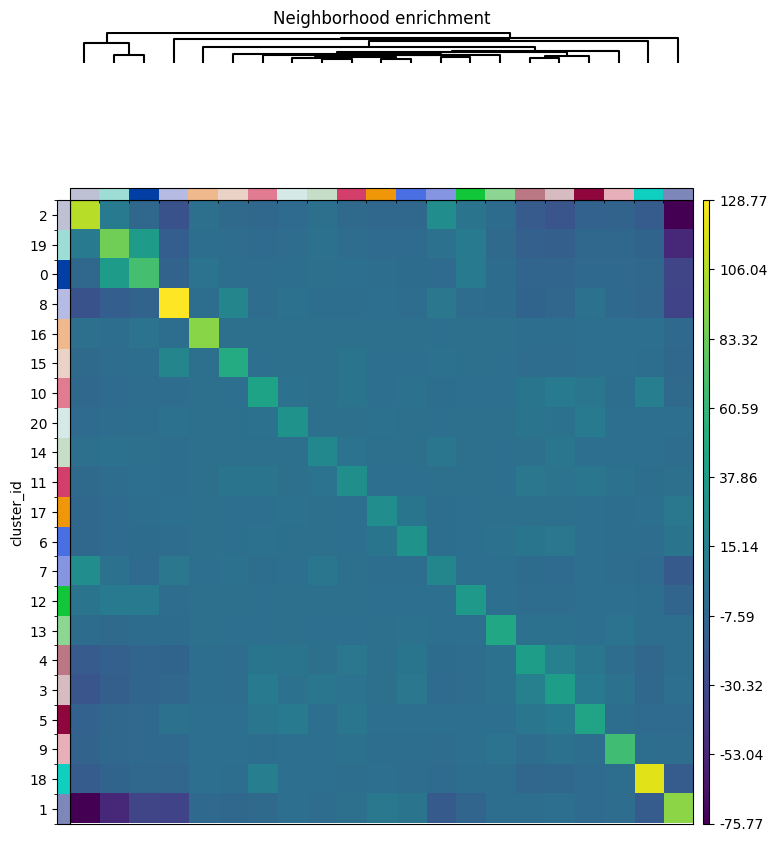

In [18]:
import numpy as np
import squidpy as sq


# @Julien : I would skip this. It does not show much...What do you think?

key_added = "cluster_id"

adata = hp.tb.spatial_pixel_neighbors(
    sdata,
    labels_name="flowsom_metaclusters",
    key_added=key_added,
    mode="most_frequent",
    grid_type="hexagon",
    size=20,
    subset=None,
)

adata.uns[f"{key_added}_nhood_enrichment"]["zscore"] = np.nan_to_num(
    adata.uns[f"{key_added}_nhood_enrichment"]["zscore"]
)
sq.pl.nhood_enrichment(adata, cluster_key=key_added, method="ward", mode="zscore", figsize=(8, 8))

# NOTE: cluster_id 0 contains all pixels that were filtered out during preprocessing

## 3. Cell clustering (FlowSOM)

Here, FlowSOM is applied at the cell level rather than directly on pixels. Harpy first combines the cell segmentation `labels_cells_instanseg` with the pixel-level FlowSOM metacluster labels `flowsom_metaclusters` to build a cell-by-feature matrix, where each row is a cell and each column represents how many pixels from a given pixel metacluster fall inside that cell.

These per-cell pixel-metacluster counts are then normalized by cell size and quantile-normalized before running FlowSOM again.

The results are stored in the table `table_cell_clustering_flowsom`. Its `.obs` contains, among other annotations, the cell-level FlowSOM cluster (`clustering`), the broader cell metacluster (`metaclustering`), and the distance to the best matching SOM node (`distance_to_bmu`). Cells with no overlap with any pixel cluster are removed from this table.

In [19]:
# Assign cell types based on FlowSOM pixel metaclusters
import flowsom as fs

batch_model = fs.models.BatchFlowSOMEstimator

sdata_crop, fsom = hp.tb.flowsom(
    sdata,
    cells_labels_name="labels_cells_instanseg",
    cluster_labels_name=["flowsom_metaclusters"],
    output_table_name="table_cell_clustering_flowsom",
    n_clusters=15,
    chunks=512,
    model=batch_model,
    num_batches=10,
    random_state=100,
    overwrite=True,
)

2026-06-17 09:55:13.412 | INFO     | harpy.table._preprocess:preprocess:318 - Calculating cell size from provided labels_name 'labels_cells_instanseg'
2026-06-17 09:55:13.529 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[raw_counts]'.
2026-06-17 09:55:14.697 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cell_clustering_flowsom' already exists. Overwriting...
2026-06-17 09:55:15.858 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-06-17 09:55:15.859 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-06-17 09:55:15.885 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.
2026-06-17 09:55:16.025 | INFO     | harpy.table.cell_clustering._clustering:flowsom:166 - Adding mean cluster intensity to '.uns['clustering']'
2026-06-17 09:55:16.037 | INFO     | harpy.table.cell_clustering._clustering:flowsom:166 - Adding mean cluster 

In [20]:
sdata["table_cell_clustering_flowsom"].obs.head()

,cell_ID,fov_labels,shapeSize,clustering,distance_to_bmu,metaclustering
cells,,,,,,
105_labels_cells_instanseg_0bbc3801,105,labels_cells_instanseg,1008.0,94,36.317707,5
129_labels_cells_instanseg_0bbc3801,129,labels_cells_instanseg,14.0,3,3.359237,10
133_labels_cells_instanseg_0bbc3801,133,labels_cells_instanseg,1389.0,90,4.964611,5
141_labels_cells_instanseg_0bbc3801,141,labels_cells_instanseg,813.0,3,3.359237,10
145_labels_cells_instanseg_0bbc3801,145,labels_cells_instanseg,885.0,3,3.359237,10


<Axes: title={'center': 'FlowSOM cell metaclusters'}>

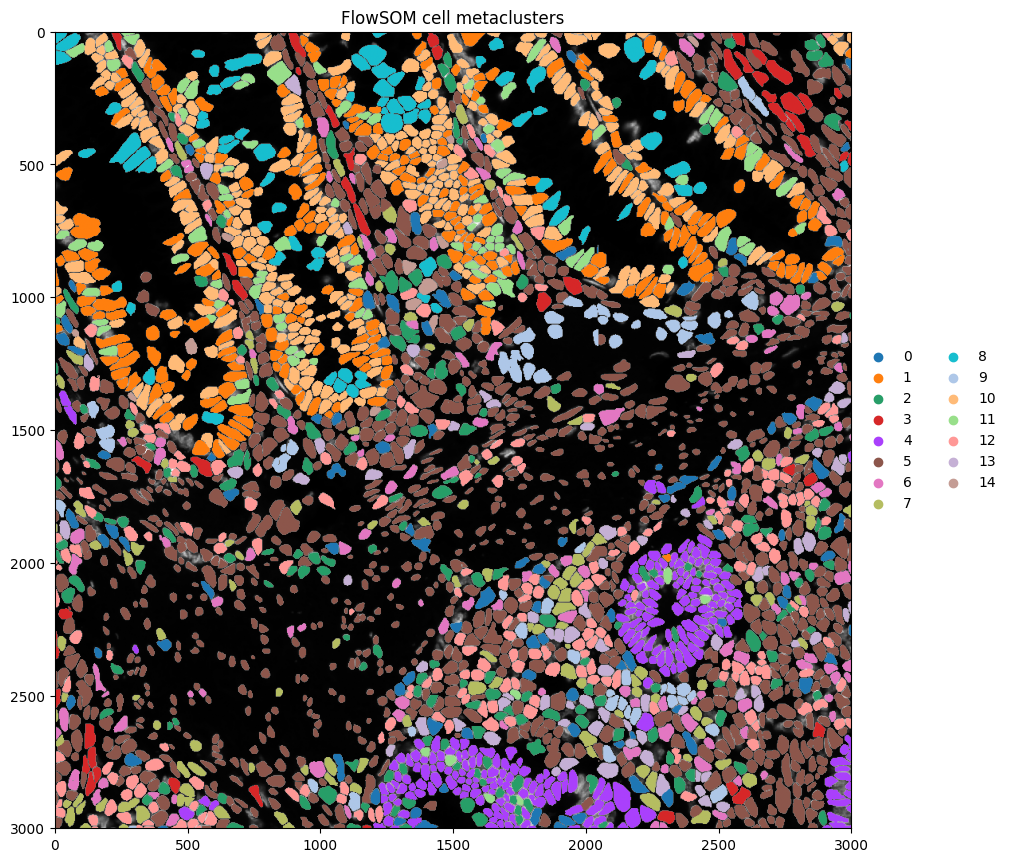

In [21]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_cell_clustering_flowsom",
    labels_name="labels_cells_instanseg",
    color="metaclustering",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={
        "title": "FlowSOM cell metaclusters",
        "colorbar": False,
        "figsize": (10, 10),
    },
)

Now also add the calculated (via hp.tb.flowsom) cell metacluster and cluster ids to the table element "table_cells_z_scored_filterd". This will allow us to calculate mean intensity per assigned metacluster, the same way as we did for the leiden clusters.

In [22]:
import pandas as pd

instance_key = "cell_ID"
region_key = "fov_labels"

table_name = "table_cells_z_scored_filterd"
table_name_flowsom_cell_clustering = "table_cell_clustering_flowsom"
labels_name = "labels_cells_instanseg"

columns = ["metaclustering", "clustering", instance_key, region_key]

index = sdata[table_name].obs.index
name = sdata[table_name].obs.index.name

sdata[table_name].obs = pd.merge(
    sdata[table_name].obs,
    sdata[table_name_flowsom_cell_clustering].obs[columns],
    on=[instance_key, region_key],
    how="left",  # left merge, because in table "table_cell_clustering_flowsom", we removed cells with no overlap with any pixel cluster
)
sdata[table_name].obs.index = index
sdata[table_name].obs.index.name = name
sdata[table_name]

# back "table_cells_z_scored_filterd", now with metaclustering and clustering keys in .obs to the zarr store.
sdata = hp.tb.add_table(
    sdata,
    adata=sdata[table_name],
    output_table_name=table_name,
    region=[labels_name],
    overwrite=True,
)

2026-06-17 09:55:57.453 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored_filterd' already exists. Overwriting...


In [23]:
sdata["table_cells_z_scored_filterd"].obs.head()

,cell_ID,fov_labels,perimeter,eccentricity,convex_area,area,filter_on_size,has_nucleus,leiden,shapeSize,metaclustering,clustering
cells,,,,,,,,,,,,
105_labels_cells_instanseg_a57cae0b,105,labels_cells_instanseg,22.182498,0.639923,30.8652,29.1312,False,True,8,1008.0,5,94
133_labels_cells_instanseg_a57cae0b,133,labels_cells_instanseg,30.026661,0.848078,43.2633,40.1421,False,True,2,1389.0,5,90
141_labels_cells_instanseg_a57cae0b,141,labels_cells_instanseg,22.634163,0.828831,25.4609,23.4957,False,True,1,813.0,10,3
145_labels_cells_instanseg_a57cae0b,145,labels_cells_instanseg,23.484163,0.618995,27.9752,25.5765,False,False,1,885.0,10,3
149_labels_cells_instanseg_a57cae0b,149,labels_cells_instanseg,22.762914,0.834278,27.0504,25.0563,False,True,5,867.0,10,3


2026-06-17 09:56:08.472 | INFO     | harpy.table._cluster_intensity:cluster_intensity:80 - Weighted (by instance size) average intensity per cluster (cluster key: 'metaclustering') will be stored in 'sdata[table_cells_z_scored_filterd].uns[metaclustering_weighted_intensity]'.
2026-06-17 09:56:12.718 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored_filterd' already exists. Overwriting...


Text(0.5, 80.7222222222222, 'cell metacluster')

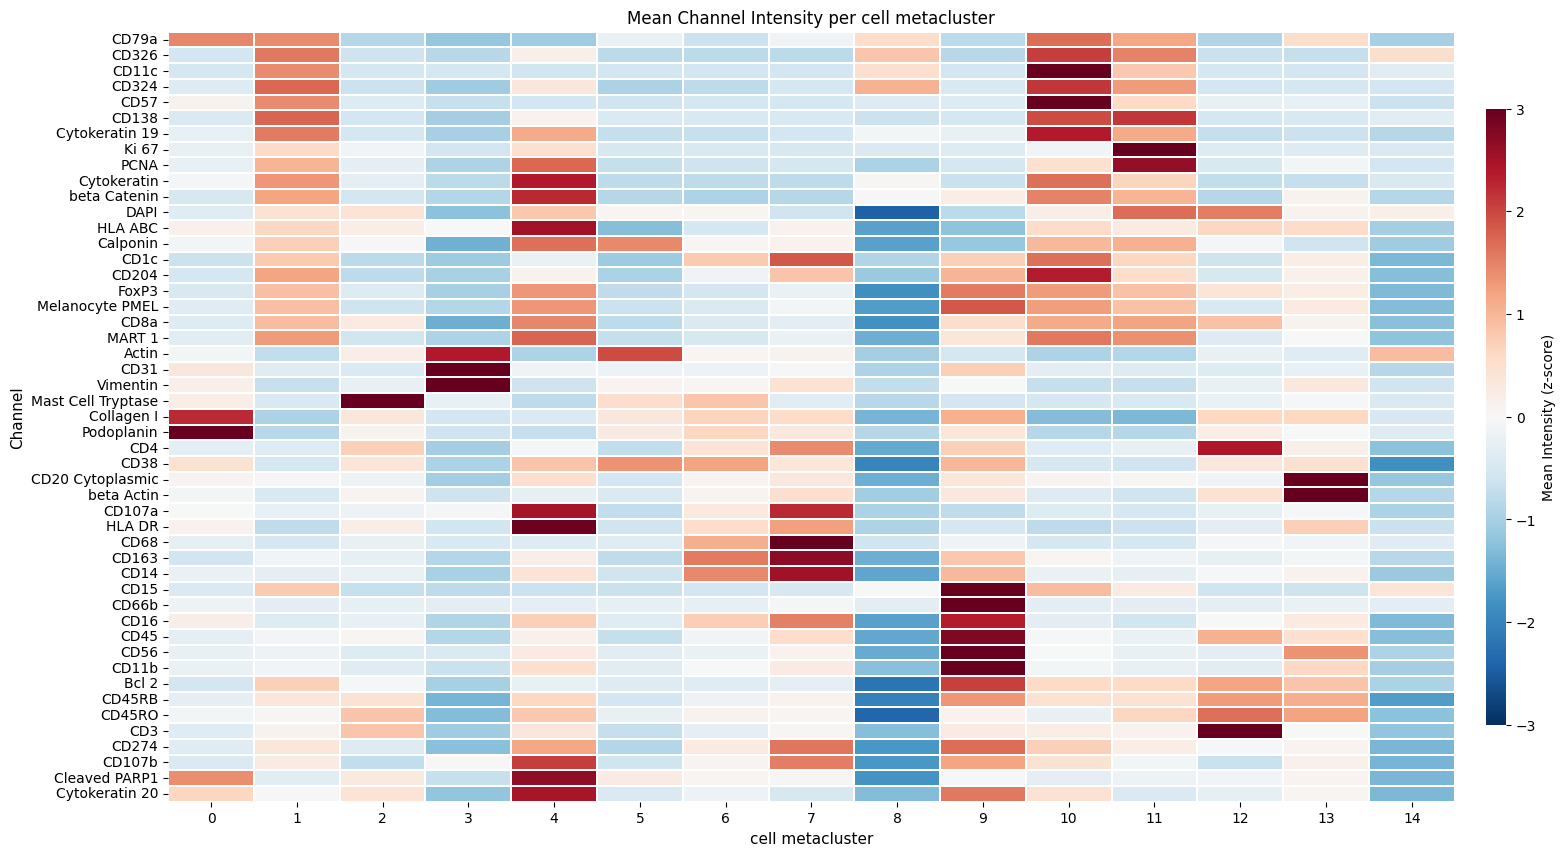

In [24]:
sdata = hp.tb.cluster_intensity(
    sdata,
    table_name=table_name,
    labels_name=labels_name,
    output_table_name=table_name,
    cluster_key="metaclustering",
    overwrite=True,
)

ax = hp.pl.cluster_intensity_heatmap(
    sdata,
    table_name=table_name,
    channels=successful_channels,
    cluster_key="metaclustering",
    figsize=(20, 10),
)
ax.set_title("Mean Channel Intensity per cell metacluster")
_x_label = "cell metacluster"

ax.set_ylabel("Channel")
ax.set_xlabel(_x_label)

In [24]:
from napari_harpy import Interactive

Interactive(sdata)